# PSD & theta from CA1 recordings


## Load LFP and packages

In [40]:
import os
import numpy as np
from pathlib import Path
from scipy import signal
from fooof import FOOOF
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
base_dir = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/LFP")

# recording (for TTL + timestamps)
rec_folder  = base_dir / "2025-07-30_16-22-55-AM/Record Node 101/experiment1/recording14"
ttl_folder  = rec_folder / "events/Acquisition_Board-102.Rhythm Data/TTL"
cont_folder = rec_folder / "continuous/Acquisition_Board-102.Rhythm Data"

# downsampled LFP
ds_path = base_dir / "downsample/RawDataChannelExtractedDS.npy"
assert ds_path.is_file(), f"Downsampled LFP not found: {ds_path}"

# ============================================================
# Sampling rates
# ============================================================
fs_raw = 2000.0
fs_ds  = 1000.0
ratio  = int(fs_raw / fs_ds)
assert fs_raw % fs_ds == 0, "fs_raw must be integer multiple of fs_ds"

# ============================================================
# Load downsampled LFP
# ============================================================
lfp_ds = np.load(ds_path, mmap_mode="r")   # (time, channels)
n_ds   = lfp_ds.shape[0]

print("Loaded LFP:", lfp_ds.shape, "fs =", fs_ds)

# ============================================================
# Load TTL and convert to DS indices
# ============================================================
stim_samp = np.load(ttl_folder / "sample_numbers.npy")
states    = np.load(ttl_folder / "states.npy")

# anchor: first continuous sample number
cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

def extract_ttl1(sample_numbers, states):
    """Return Nx2 array of [start, end] sample numbers (RAW grid)."""
    start_idx = np.where(states == 1)[0]
    end_idx   = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    pulses = np.stack(
        [sample_numbers[start_idx[:n]],
         sample_numbers[end_idx[:n]]],
        axis=1
    )
    return pulses[pulses[:, 1] > pulses[:, 0]]

# TTL in raw sample numbers
pulses_raw = extract_ttl1(stim_samp, states)

# convert → raw indices relative to LFP start
pulses_idx = (pulses_raw - cont0).astype(np.int64)

# convert → downsampled indices
pulses_ds = pulses_idx // ratio

# safety clipping
pulses_ds[:, 0] = np.clip(pulses_ds[:, 0], 0, n_ds - 1)
pulses_ds[:, 1] = np.clip(pulses_ds[:, 1], 0, n_ds - 1)
pulses_ds = pulses_ds[pulses_ds[:, 1] > pulses_ds[:, 0]]

print("TTL1 pulses (DS):", pulses_ds.shape)

Loaded LFP: (195968, 32) fs = 1000.0
TTL1 pulses (DS): (651, 2)


In [41]:

def bandpass_150_250(x, fs, order=4):
    """Stable zero-phase bandpass using SOS."""
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    sos = signal.butter(order, [150/nyq, 250/nyq], btype="bandpass", output="sos")
    return signal.sosfiltfilt(sos, x)

def contiguous_segments(mask):
    """Return list of (start, end) index pairs for True segments in a boolean mask."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    edges = np.diff(mask.astype(np.int8), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0]
    return list(zip(starts, ends))

def events_from_mask(mask, fs, min_dur_ms=15, envelope=None):
    """
    Convert threshold mask into events with start/end/peak.
    envelope: optional array for peak finding (defaults to None).
    """
    min_len = int(round(fs * min_dur_ms / 1000.0))
    ev = []
    for s, e in contiguous_segments(mask):
        if (e - s) < min_len:
            continue
        if envelope is None:
            peak = (s + e) // 2
            pkval = np.nan
        else:
            peak = s + int(np.argmax(envelope[s:e]))
            pkval = float(envelope[peak])
        ev.append(dict(start=s, end=e, peak=peak, peak_value=pkval,
                       start_s=s/fs, end_s=e/fs, peak_s=peak/fs,
                       duration_ms=(e - s) * 1000.0 / fs))
    return ev

 #  #  # CHANGE LATER!!!!Define a flexible “stim mask” naming system

In [42]:

def build_stim_mask(
    n_samples: int,
    pulses_ds: np.ndarray,
    fs: float,
    stim_mode: str = "pulse_window",
    # --- options you may tweak later ---
    pulse_pad_s: float = 1.0,     # include padding around each TTL pulse
    pulse_min_gap_s: float = 1.0, # merge pulses into trains if gaps <= this (for "train" mode)
    train_pre_s: float = 0.0,     # expand each train earlier
    train_post_s: float = 0.0,    # expand each train later
):
    """
    Returns stim_mask (bool array length n_samples).

    stim_mode options:
      - "pulse_only": only [pulse start, pulse end]
      - "pulse_window": pulses expanded by ±pulse_pad_s
      - "train_window": merge close pulses into trains, then expand by pre/post
    """
    stim_mask = np.zeros(n_samples, dtype=bool)
    if pulses_ds is None or len(pulses_ds) == 0:
        return stim_mask

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        return stim_mask

    if stim_mode in ("pulse_only", "pulse_window"):
        pad = int(round(pulse_pad_s * fs)) if stim_mode == "pulse_window" else 0
        for s, e in pulses:
            s0 = max(0, int(s) - pad)
            e0 = min(n_samples, int(e) + pad)
            stim_mask[s0:e0] = True
        return stim_mask

    if stim_mode == "train_window":
        # Merge pulses into trains if close together
        gap = int(round(pulse_min_gap_s * fs))
        trains = []
        cur_s, cur_e = int(pulses[0, 0]), int(pulses[0, 1])
        for s, e in pulses[1:]:
            s, e = int(s), int(e)
            if s - cur_e <= gap:
                cur_e = max(cur_e, e)
            else:
                trains.append((cur_s, cur_e))
                cur_s, cur_e = s, e
        trains.append((cur_s, cur_e))

        pre  = int(round(train_pre_s * fs))
        post = int(round(train_post_s * fs))
        for s, e in trains:
            s0 = max(0, s - pre)
            e0 = min(n_samples, e + post)
            stim_mask[s0:e0] = True
        return stim_mask

    raise ValueError(f"Unknown stim_mode: {stim_mode}")

In [43]:
import numpy as np

def bipolar(lfp, ch1, ch2):
    return np.asarray(lfp[:, ch1] - lfp[:, ch2], dtype=np.float32)

def ttl_exclusion_mask(n_samples, pulses_ds, fs, pad_s=1.0):
    """
    Returns mask=True for samples to KEEP (baseline),
    excluding TTL windows expanded by ±pad_s.
    """
    mask = np.ones(n_samples, dtype=bool)
    if pulses_ds is None or len(pulses_ds) == 0:
        return mask

    pad = int(round(pad_s * fs))
    for s, e in np.asarray(pulses_ds, dtype=np.int64):
        s0 = max(0, int(s) - pad)
        e0 = min(n_samples, int(e) + pad)
        mask[s0:e0] = False
    return mask

Welch PSD (0.5 s window, 0.25 s overlap), 1–200 Hz

In [44]:
from scipy import signal

def contiguous_true_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    d = np.diff(mask.astype(np.int8))
    starts = np.where(d == 1)[0] + 1
    ends   = np.where(d == -1)[0] + 1
    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size]
    return list(zip(starts, ends))

def welch_psd_from_mask(x, fs, mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200):
    x = np.asarray(x, dtype=np.float32)
    nperseg  = int(round(win_s * fs))
    noverlap = int(round(overlap_s * fs))
    assert nperseg > 0 and 0 <= noverlap < nperseg

    segs = contiguous_true_segments(mask)
    psds = []
    f_ref = None

    for s, e in segs:
        if (e - s) < nperseg:
            continue
        f, Pxx = signal.welch(x[s:e], fs=fs, nperseg=nperseg, noverlap=noverlap)
        if f_ref is None:
            f_ref = f
        psds.append(Pxx)

    if len(psds) == 0:
        raise ValueError("No usable data for Welch PSD (mask too strict or recording too short).")

    Pxx_mean = np.mean(np.vstack(psds), axis=0)
    sel = (f_ref >= fmin) & (f_ref <= fmax)
    return f_ref[sel], Pxx_mean[sel]

Compute PSD for STIM and NO_STIM (RIGHT + LEFT)

STIM seconds: 105.259
NO_STIM seconds: 90.709


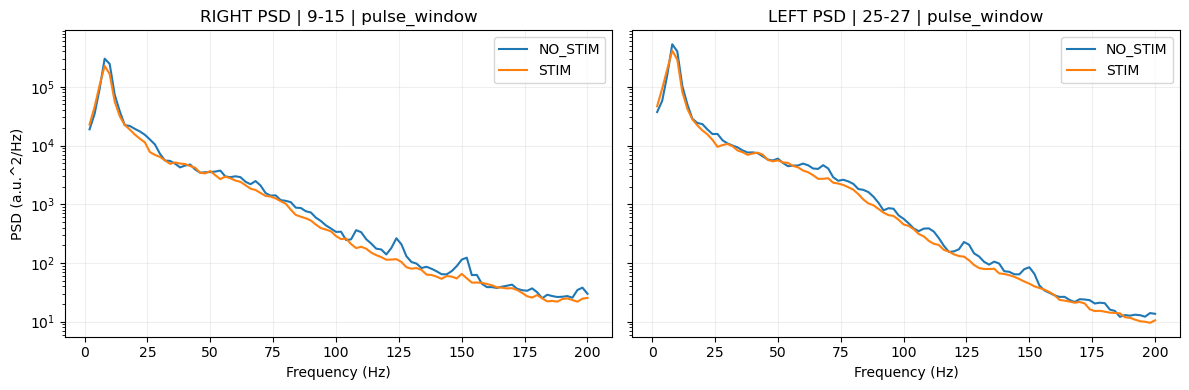

In [45]:
# --- REQUIRED: lfp_ds, fs, pulses_ds already defined ---
fs = 1000.0
n = lfp_ds.shape[0]

# Choose your stim definition HERE (easy to change later)
stim_def = dict(
    stim_mode="pulse_window",   # "pulse_only" | "pulse_window" | "train_window"
    pulse_pad_s=0.3,            # start with 0.0 = only pulse duration; later you might set 0.1 or 1.0
    pulse_min_gap_s=1.0,        # used only for train_window
    train_pre_s=0.0,
    train_post_s=0.0,
)

stim_mask = build_stim_mask(n, pulses_ds, fs, **stim_def)
nostim_mask = ~stim_mask

print("STIM seconds:", stim_mask.sum() / fs)
print("NO_STIM seconds:", nostim_mask.sum() / fs)

pairs = {"RIGHT": (9, 15), "LEFT": (25, 27)}

psd = {}  # psd[hemi][cond] = (f, Pxx)

for hemi, (c1, c2) in pairs.items():
    x = (lfp_ds[:, c1] - lfp_ds[:, c2]).astype(np.float32)

    f, P_stim = welch_psd_from_mask(x, fs, stim_mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200)
    _, P_base = welch_psd_from_mask(x, fs, nostim_mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200)

    psd[hemi] = {
        "STIM": (f, P_stim),
        "NO_STIM": (f, P_base)
    }

# ---- Plot: each hemisphere gets STIM vs NO_STIM ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, hemi in zip(axes, ["RIGHT", "LEFT"]):
    f, P_stim = psd[hemi]["STIM"]
    _, P_base = psd[hemi]["NO_STIM"]

    ax.semilogy(f, P_base, label="NO_STIM")
    ax.semilogy(f, P_stim, label="STIM")
    ax.set_title(f"{hemi} PSD | {pairs[hemi][0]}-{pairs[hemi][1]} | {stim_def['stim_mode']}")
    ax.set_xlabel("Frequency (Hz)")
    ax.grid(True, alpha=0.2)
    ax.legend()

axes[0].set_ylabel("PSD (a.u.^2/Hz)")
plt.tight_layout()
plt.show()

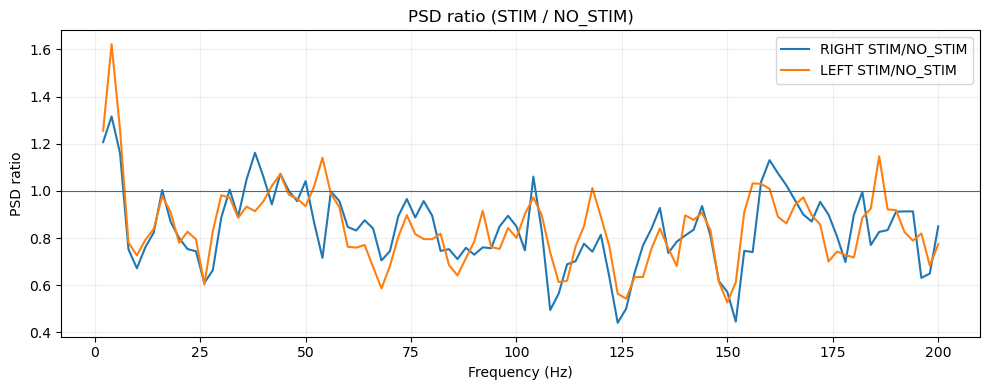

In [46]:
plt.figure(figsize=(10, 4))

for hemi in ["RIGHT", "LEFT"]:
    f, P_stim = psd[hemi]["STIM"]
    _, P_base = psd[hemi]["NO_STIM"]
    ratio = P_stim / (P_base + 1e-20)
    plt.plot(f, ratio, label=f"{hemi} STIM/NO_STIM")

plt.axhline(1.0, lw=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD ratio")
plt.title("PSD ratio (STIM / NO_STIM)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

Compute PSD for one bipolar signal, STIM vs NO-STIM

In [47]:
def contiguous_true_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    d = np.diff(mask.astype(np.int8))
    starts = np.where(d == 1)[0] + 1
    ends   = np.where(d == -1)[0] + 1
    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size]
    return list(zip(starts, ends))

def welch_psd_from_mask(x, fs, mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200):
    x = np.asarray(x, dtype=np.float32)
    nperseg  = int(round(win_s * fs))
    noverlap = int(round(overlap_s * fs))
    segs = contiguous_true_segments(mask)

    psds = []
    f_ref = None

    for s, e in segs:
        if (e - s) < nperseg:
            continue
        f, Pxx = signal.welch(x[s:e], fs=fs, nperseg=nperseg, noverlap=noverlap)
        if f_ref is None:
            f_ref = f
        psds.append(Pxx)

    if len(psds) == 0:
        raise ValueError("No usable segments for Welch (mask too strict or windows too short).")

    Pxx_mean = np.mean(np.vstack(psds), axis=0)
    sel = (f_ref >= fmin) & (f_ref <= fmax)
    return f_ref[sel], Pxx_mean[sel]

In [48]:
def bipolar(lfp, ch1, ch2):
    return (lfp[:, ch1] - lfp[:, ch2]).astype(np.float32)

FOOOF fitting in two ranges (3–15 and 15–150), then grab theta peak (5–12)

In [ ]:
def fit_fooof_two_ranges(freqs, psd, peak_width_limits=(1, 12), max_n_peaks=6, min_peak_height=0.1):
    """
    Fit FOOOF separately in:
      - low: 3–15 Hz
      - high: 15–150 Hz
    Return both models.
    """
    fm_low = FOOOF(
        peak_width_limits=peak_width_limits,
        max_n_peaks=max_n_peaks,
        min_peak_height=min_peak_height,
        aperiodic_mode="fixed",
        verbose=False
    )
    fm_high = FOOOF(
        peak_width_limits=peak_width_limits,
        max_n_peaks=max_n_peaks,
        min_peak_height=min_peak_height,
        aperiodic_mode="fixed",
        verbose=False
    )

    fm_low.fit(freqs, psd, freq_range=[3, 15])
    fm_high.fit(freqs, psd, freq_range=[15, 150])

    return fm_low, fm_high

def extract_theta_from_low_model(fm_low, theta_band=(5, 12)):
    """
    From the LOW-range FOOOF model, pick the strongest peak whose center freq is in theta band.
    Returns dict with:
      - theta_cf (Hz)
      - theta_pw (relative power above aperiodic, in log10 units)
      - theta_bw (bandwidth, Hz)
    If no theta peak found, returns None.
    """
    peaks = fm_low.get_params('peak_params')  # array: [CF, PW, BW]
    if peaks is None or len(peaks) == 0:
        return None

    peaks = np.asarray(peaks)
    in_band = (peaks[:, 0] >= theta_band[0]) & (peaks[:, 0] <= theta_band[1])
    cand = peaks[in_band]
    if cand.size == 0:
        return None

    # choose largest PW (height above aperiodic)
    best = cand[np.argmax(cand[:, 1])]
    return {"theta_cf": float(best[0]), "theta_pw": float(best[1]), "theta_bw": float(best[2])}

	 # theta_cf = theta peak center frequency (Hz) from the Gaussian peak FOOOF fit
	 # theta_pw = peak height above the aperiodic background (FOOOF “power” parameter; in log10 PSD units)
	 # theta_bw = bandwidth (Hz) of that Gaussian peak

def get_aperiodic_params(fm):
    ap = fm.get_params('aperiodic_params')
    # fixed mode: [offset, exponent]
    return {"offset": float(ap[0]), "exponent": float(ap[1])}

In [51]:
fs = fs_ds
n = lfp_ds.shape[0]

# 1) define what "stim" means (you can tweak later)
stim_mask = build_stim_mask(
    n_samples=n,
    pulses_ds=pulses_ds,
    fs=fs,
    stim_mode="pulse_window",   # <- change later if you want
    pulse_pad_s=1.0             # TTL ± 1s (your current choice)
)

# 2) baseline = everything except stim (and optionally minus artifacts later)
baseline_mask = ~stim_mask

print("stim fraction:", stim_mask.mean())
print("baseline fraction:", baseline_mask.mean())

stim fraction: 0.7653239304376225
baseline fraction: 0.23467606956237752


In [56]:
fs = 1000.0  # Hz

# Bipolar channel pairs
channel_pairs = {
    "RIGHT": (9, 15),
    "LEFT":  (25, 27),
}

results = {}

for hemi, (ch_a, ch_b) in channel_pairs.items():

    # ------------------------
    # Bipolar LFP
    # ------------------------
    lfp_bipolar = bipolar(lfp_ds, ch_a, ch_b)

    # ------------------------
    # PSD (Welch)
    # ------------------------
    freqs, psd_stim = welch_psd_from_mask(
        lfp_bipolar, fs, stim_mask,
        win_s=0.5, overlap_s=0.25,
        fmin=1, fmax=200
    )

    _, psd_baseline = welch_psd_from_mask(
        lfp_bipolar, fs, baseline_mask,
        win_s=0.5, overlap_s=0.25,
        fmin=1, fmax=200
    )

    # ------------------------
    # FOOOF fits (low freq range only)
    # ------------------------
    fooof_low_stim, _ = fit_fooof_two_ranges(freqs, psd_stim)
    fooof_low_base, _ = fit_fooof_two_ranges(freqs, psd_baseline)

    # ------------------------
    # Theta metrics (5–12 Hz)
    # ------------------------
    theta_stim = extract_theta_from_low_model(
        fooof_low_stim, theta_band=(5, 12)
    )

    theta_baseline = extract_theta_from_low_model(
        fooof_low_base, theta_band=(5, 12)
    )

    # ------------------------
    # Store results
    # ------------------------
    results[hemi] = {
        "PSD": {
            "freqs": freqs,
            "STIM": psd_stim,
            "BASELINE": psd_baseline,
        },
        "FOOOF": {
            "STIM": fooof_low_stim,
            "BASELINE": fooof_low_base,
        },
        "THETA": {
            "STIM": theta_stim,
            "BASELINE": theta_baseline,
        },
        "APERIODIC": {
            "STIM": get_aperiodic_params(fooof_low_stim),
            "BASELINE": get_aperiodic_params(fooof_low_base),
        },
    }

    stim_cf = np.nan if theta_stim is None else theta_stim["theta_cf"]
    base_cf = np.nan if theta_baseline is None else theta_baseline["theta_cf"]

    print(f"{hemi} | Theta CF STIM={stim_cf:.2f} Hz, BASELINE={base_cf:.2f} Hz")

RIGHT | Theta CF STIM=8.47 Hz, BASELINE=8.70 Hz
LEFT | Theta CF STIM=8.47 Hz, BASELINE=8.69 Hz


Plot: PSD + aperiodic fits + theta peak markers (STIM vs NO-STIM)


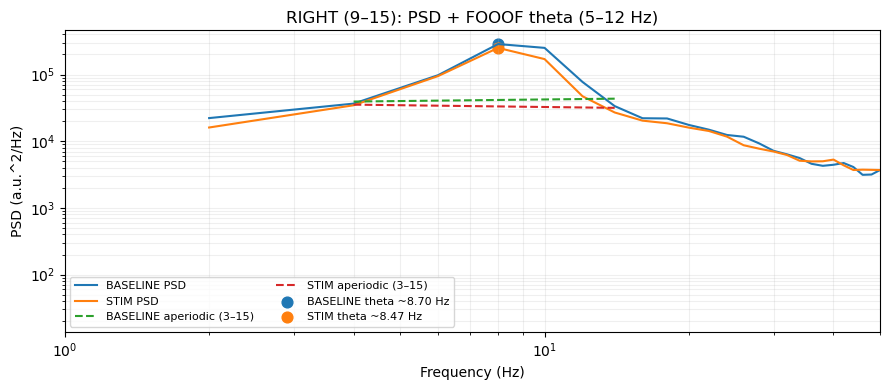

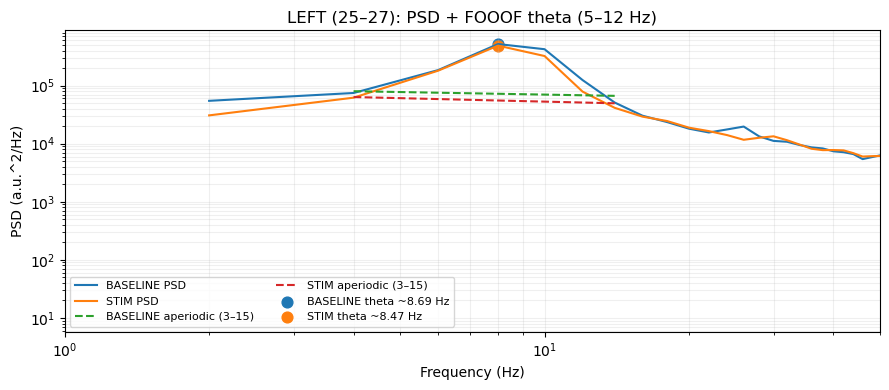

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def aperiodic_curve(freqs, offset, exponent):
    """
    FOOOF 'fixed' aperiodic in log10 power:
      log10(P) = offset - exponent * log10(f)
    so P = 10**offset * f**(-exponent)
    """
    freqs = np.asarray(freqs, dtype=float)
    return (10 ** offset) * (freqs ** (-exponent))

def plot_fooof_theta_comparison(res_hemi, hemi_label, xlim=(1, 50)):
    # ---- unpack from YOUR nested structure ----
    f = np.asarray(res_hemi["PSD"]["freqs"])
    P_stim = np.asarray(res_hemi["PSD"]["STIM"])
    P_base = np.asarray(res_hemi["PSD"]["BASELINE"])

    fm_stim = res_hemi["FOOOF"]["STIM"]
    fm_base = res_hemi["FOOOF"]["BASELINE"]

    th_stim = res_hemi["THETA"]["STIM"]       # dict or None
    th_base = res_hemi["THETA"]["BASELINE"]   # dict or None

    ap_stim = res_hemi["APERIODIC"]["STIM"]       # {"offset":..., "exponent":...}
    ap_base = res_hemi["APERIODIC"]["BASELINE"]

    fig, ax = plt.subplots(figsize=(9, 4))

    # PSD (log-log)
    ax.loglog(f, P_base, label="BASELINE PSD")
    ax.loglog(f, P_stim, label="STIM PSD")

    # aperiodic curves (plot only in 3–15 Hz since that's what you fit in fm_low)
    low_sel = (f >= 3) & (f <= 15)
    f_low = f[low_sel]

    P_ap_base = aperiodic_curve(f_low, ap_base["offset"], ap_base["exponent"])
    P_ap_stim = aperiodic_curve(f_low, ap_stim["offset"], ap_stim["exponent"])

    ax.loglog(f_low, P_ap_base, "--", label="BASELINE aperiodic (3–15)")
    ax.loglog(f_low, P_ap_stim, "--", label="STIM aperiodic (3–15)")

    # theta markers (theta_cf keys)
    for lab, th, y_psd in [("BASELINE", th_base, P_base), ("STIM", th_stim, P_stim)]:
        if th is not None:
            cf = float(th["theta_cf"])
            idx = int(np.argmin(np.abs(f - cf)))
            ax.scatter([f[idx]], [y_psd[idx]], s=60, label=f"{lab} theta ~{cf:.2f} Hz")

    ax.set_xlim(*xlim)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (a.u.^2/Hz)")
    ax.set_title(f"{hemi_label}: PSD + FOOOF theta (5–12 Hz)")
    ax.grid(True, which="both", alpha=0.2)
    ax.legend(fontsize=8, ncols=2)
    plt.tight_layout()
    plt.show()

# call it
plot_fooof_theta_comparison(results["RIGHT"], "RIGHT (9–15)")
plot_fooof_theta_comparison(results["LEFT"],  "LEFT (25–27)")

Paired-dot plots (STIM vs NO-STIM)

In [64]:
import matplotlib.pyplot as plt
import numpy as np

def paired_dotplot(ax, values_off, values_on, ylabel, title):
    values_off = np.asarray(values_off)
    values_on  = np.asarray(values_on)

    x0, x1 = 0, 1

    # connecting lines
    for i in range(len(values_off)):
        ax.plot(
            [x0, x1],
            [values_off[i], values_on[i]],
            color="0.6",
            linewidth=1.2,
            zorder=1
        )

    # dots
    ax.scatter(
        np.full_like(values_off, x0),
        values_off,
        s=50,
        color="black",
        zorder=2
    )
    ax.scatter(
        np.full_like(values_on, x1),
        values_on,
        s=50,
        color="black",
        zorder=2
    )

    # axes styling (Nature style)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["NO STIM", "STIM"])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)

    # remove grid
    ax.grid(False)

    # thicker spines, hide top/right
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(width=1.5, length=5)

In [65]:
# Choose condition names ONCE
COND_ON  = "STIM"
COND_OFF = "BASELINE"   # this is your NO-STIM condition

theta_freq_off = []
theta_freq_on  = []

theta_pow_off = []
theta_pow_on  = []

aper_exp_off = []
aper_exp_on  = []

for hemi in ["RIGHT", "LEFT"]:
    th_off = results[hemi]["THETA"][COND_OFF]   # dict or None
    th_on  = results[hemi]["THETA"][COND_ON]

    # If FOOOF didn't find a theta peak, th_* can be None
    theta_freq_off.append(np.nan if th_off is None else th_off["theta_cf"])
    theta_freq_on.append( np.nan if th_on  is None else th_on["theta_cf"])

    theta_pow_off.append(np.nan if th_off is None else th_off["theta_pw"])
    theta_pow_on.append( np.nan if th_on  is None else th_on["theta_pw"])

    aper_exp_off.append(results[hemi]["APERIODIC"][COND_OFF]["exponent"])
    aper_exp_on.append( results[hemi]["APERIODIC"][COND_ON]["exponent"])

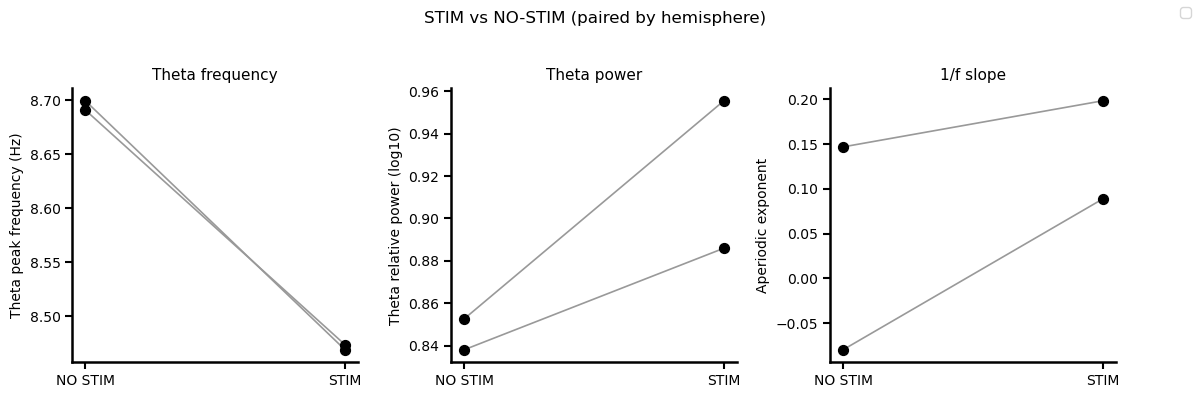

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

# 1) Theta peak frequency
paired_dotplot(
    axes[0],
    theta_freq_off,
    theta_freq_on,
    ylabel="Theta peak frequency (Hz)",
    title="Theta frequency"
)

# 2) Theta relative power (FOOOF peak height)
paired_dotplot(
    axes[1],
    theta_pow_off,
    theta_pow_on,
    ylabel="Theta relative power (log10)",
    title="Theta power"
)

# 3) Aperiodic exponent (1/f slope)
paired_dotplot(
    axes[2],
    aper_exp_off,
    aper_exp_on,
    ylabel="Aperiodic exponent",
    title="1/f slope"
)

# Legend only once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

fig.suptitle("STIM vs NO-STIM (paired by hemisphere)", fontsize=12)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

## Extracting SWRs and determining main properties 

First extraction of SWR peaks, initiation, end and width

In [ ]:
# 3 sd threshold
peaks, properties = find_peaks(proj_CA1W0Lcwt, prominence=1, width=20, height=sd3proj_CA1cwt)
properties["prominences"], properties["widths"]

# SWR boundaries taken at 70% from peak of intensity. This means that the SWRs with small amplitude will be longer than the big ones.
results_width = peak_widths(proj_CA1W0Lcwt, peaks, rel_height=0.7)

# Organise results in numpy array
peaks2 = peaks.reshape(len(peaks),1)
npresults_width = np.array(results_width).reshape(4,-1)
SWR_prop = np.append(peaks2, results_width).reshape(5,len(peaks2)).round()

Display subset

Second extraction of main frequency and power 

In [ ]:
projMaxP_cwtmg = np.max(CA1cwtWake0lib, axis = 0)
projMaxF_cwtmg = np.argmax(CA1cwtWake0lib, axis = 0) + 120
projMaxP_cwtmg.shape

nb_SWR = len(peaks)
data = np.zeros((nb_SWR,4))

for tt in np.arange(nb_SWR):
    SWR_start = int(SWR_prop[3,tt])
    SWR_stop = int(SWR_prop[4,tt])
    SWR_MaxP = projMaxP_cwtmg[SWR_start:SWR_stop]
    SWR_MaxF = projMaxF_cwtmg[SWR_start:SWR_stop]
    data[tt, 0] = max(SWR_MaxF).round()
    data[tt, 1] = max(SWR_MaxP).round()
    data[tt, 2] = round(sum(SWR_MaxF)/len(SWR_MaxF))
    data[tt, 3] = round(sum(SWR_MaxP)/len(SWR_MaxP))

param_SWR = pd.DataFrame(data, columns = ['Max freq', 'Max int', 'Avg freq', 'Avg int'])
tSWR_prop = SWR_prop.transpose()
pd_prop_SWR = pd.DataFrame(tSWR_prop, columns = ['peak time', 'Duration', 'peak amp', 'start time', 'end time'])
pd_tokeep = pd.DataFrame(np.ones(nb_SWR).astype(bool), columns = ['toKeep'])
All_SWR = pd.concat([pd_tokeep,pd_prop_SWR, param_SWR], axis=1)

SWR_peak = peaks
SWR_start = SWR_prop[3,:].astype(int)
SWR_end = SWR_prop[4,:].astype(int)

### Store the results in All_SWR_prop pd dataframe and save as pkl/csv for post processing.

End of Notebook. 

In [ ]:
filename2 = os.path.join(dpath,f'SWRproperties{suffix}.pkl')
filename3 = os.path.join(dpath,f'SWRproperties{suffix}.csv')
All_SWR.to_pickle(filename2)
All_SWR.to_csv(filename3, sep = ',')

combined = np.stack([CA1, filt_CA1, proj_CA1W0Ccwt, proj_CA1W0Lcwt], axis = 1)
filenameC = os.path.join(dpath,f'SignalCA1.npy')
np.save(filenameC, combined)

sample_rate = 1000.
t_start = 0.
# if done and no intention to display for assessment
#%reset
#plt.close('all')

### Display and asses SWRs

#### ephys viewer to check SWR detection

In [ ]:
%%capture
%gui qt

app = mkQApp()

#Create one data source with 3 event channel
all_events = []
conditions = ['All','Good','Bad']
for c,cond in enumerate(conditions):
    match cond:
        case 'All':
            selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
        case 'Good':
            selection = "All_SWR['toKeep']"
        case 'Bad':
            selection = "~All_SWR['toKeep']"
    ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
    ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
    all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
source_ev = InMemoryEventSource(all_events=all_events)

combined = np.stack([CA1, fCA1wake0C, proj_CA1W0Lcwt, proj_CA1W0Ccwt, TTL], axis = 1)

sample_rate = 1000.
t_start = 0.

#create 2 familly scatters from theses 2 indexes
scatter_indexes = {0: SWR_peak, 1: SWR_start, 2: SWR_end}
#and asign them to some channels each
scatter_channels = {0: [1, 2], 1: [0, 1], 2: [0, 1]}
source = AnalogSignalSourceWithScatter(combined, sample_rate, t_start, scatter_indexes, scatter_channels)

#Create the main window that can contain several viewers
win = MainViewer(debug=True, show_auto_scale=True)

#create a viewer for signal with TraceViewer
#connected to the signal source
view1 = TraceViewer(source=source)

#Parameters can be set in script
view1.params['scale_mode'] = 'same_for_all'
view1.params['display_labels'] = True
view1.auto_scale()

nCh = len(view1.by_channel_params.children())
mult = 5
for ch in range(nCh):
    match ch%mult:
        case 0: # raw traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 2.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.05
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 1: # filtered traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#0055ff'
        case 2: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ff5500'
        case 3: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 4: # TTL
            view1.by_channel_params[f'ch{ch}', 'offset'] = 4.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
view1.params['ylim_max']=5*int((nCh+1)/mult)
view1.params['ylim_min']=0

view2 = EventList(source=source_ev, name='event')


#put this viewer in the main window
win.add_view(view1)
win.add_view(view2, location='bottom',  orientation='horizontal')

#Run
win.show()

#### Select and deselect SWRs

In [ ]:
def clicked(arg):
    selectedEvent = view2.list_widget.currentItem().text()
    selectedSWR = int(selectedEvent.split('SWR')[1])
    #print(selectedSWR)
    match arg.description:
        case 'Keep SWR':
            All_SWR.loc[selectedSWR,'toKeep']=True
            print(f'SWR {selectedSWR} restored')
        case 'Discard SWR':
            All_SWR.loc[selectedSWR,'toKeep']=False
            print(f'SWR {selectedSWR} discarded')
    #save modif
    All_SWR.to_pickle(filename2)
    All_SWR.to_csv(filename3, sep = ',')
    #Create one data source with 3 event channel
    all_events = []
    conditions = ['All','Good','Bad']
    for c,cond in enumerate(conditions):
        match cond:
            case 'All':
                selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
            case 'Good':
                selection = "All_SWR['toKeep']"
            case 'Bad':
                selection = "~All_SWR['toKeep']"
        ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
        ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
        all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
    source_ev = InMemoryEventSource(all_events=all_events)
    view2.source = source_ev
    view2.refresh_list(view2.combo.currentIndex())

button_Good = widgets.Button(description = 'Keep SWR')   
button_Good.on_click(clicked)

button_Bad = widgets.Button(description = 'Discard SWR')   
button_Bad.on_click(clicked)

display(button_Good, button_Bad)



In [ ]:
# plotting the points
plt.scatter(np.zeros(len(MaxSWR)), MaxSWR)
plt.scatter(np.ones(len(AvgSWR)), AvgSWR)


In [ ]:
# plotting the lines
for i in range(len(MaxSWR)):
    plt.plot( [0,1], [MaxSWR[i], AvgSWR[i]], c='k')
